<a href="https://colab.research.google.com/github/shuyu-d/IDL_TP/blob/master/tp4_idl_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 4 (Exercice 4.5) - Modèle de régression logistique

Dans ce TP, nous implémentons les fonctions pour le calcul du risque empirique du modèle de régression logistique ainsi que son gradient. 

Les données d'observation appartiennent au jeu de données Iris, déjà disponible via scikit-learn (`sklearn datasets`, voir "Préparation du jeu de données"). Plus d'information sur ce jeu de données : https://scikit-learn.org/1.4/auto_examples/datasets/plot_iris_dataset.html,   https://archive.ics.uci.edu/dataset/53/iris. 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
pd.set_option('display.expand_frame_repr', False)
from sklearn import datasets

### Préparation du jeu de données 
Ce jeu de données contient trois espèces différentes d’iris (Setosa, Versicolour et Virginica), caractérisées par la longueur et la largeur des sépales et des pétales. 
Les données sont stockées dans un tableau NumPy de dimension 150 x 4.

Les lignes correspondent aux observations (échantillons) et les colonnes représentent respectivement : longueur du sépale, largeur du sépale, longueur du pétale et largeur du pétale.

In [19]:
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['label'] = [iris.target_names[y] for y in iris.target]
iris_df.sample(frac=1).head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
106,4.9,2.5,4.5,1.7,virginica
91,6.1,3.0,4.6,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
67,5.8,2.7,4.1,1.0,versicolor
18,5.7,3.8,1.7,0.3,setosa
2,4.7,3.2,1.3,0.2,setosa
52,6.9,3.1,4.9,1.5,versicolor
104,6.5,3.0,5.8,2.2,virginica
82,5.8,2.7,3.9,1.2,versicolor
0,5.1,3.5,1.4,0.2,setosa


### Classification binaire (Setosa versus non-Setosa) 
Avec le jeu de données Iris, on considère le problème de classification binaire qui vise à distinguer l'espèce Setosa des deux autres$^*$. Ainsi, la classe binaire $y_i$ de chaque échantillon est définie par 
 * $y_i = 0$ si le label de l'échantillon est 'setosa'. On appelle cette classe 'setosa'
 * $y_1 = 1$ sinon. On appelle cette classe 'non-setosa'. 


In [20]:
iris_data = iris.data.copy() 
bin_target = iris.target.copy()
bin_target_names = iris.target_names.copy()
bin_target[ bin_target != 0] = 1
bin_target_names[bin_target_names != bin_target_names[0]] = 'non-setosa'

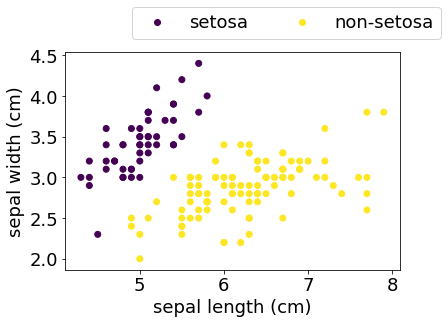

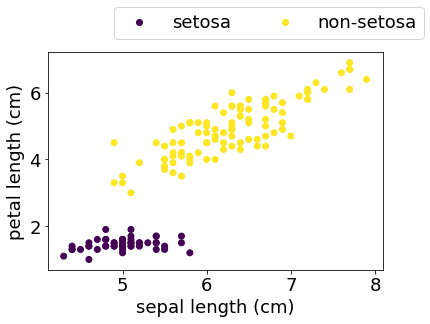

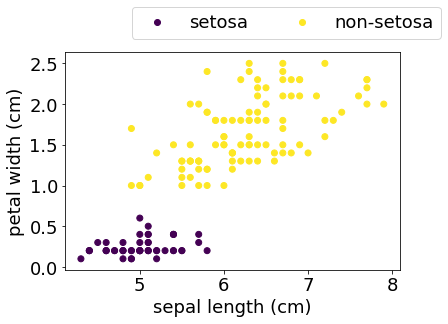

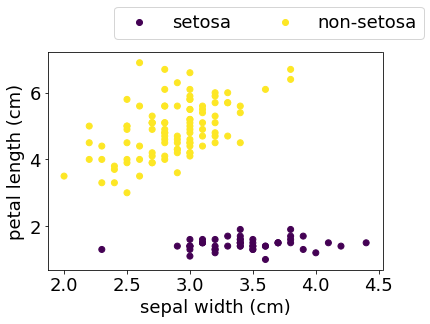

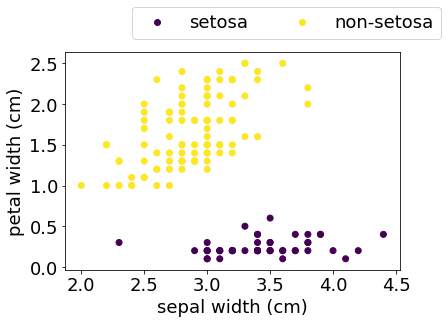

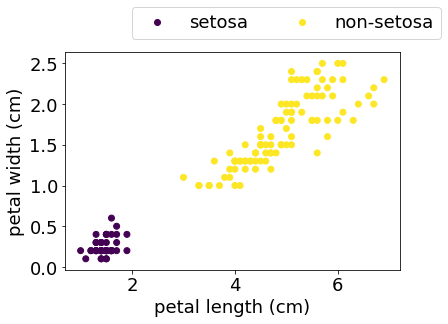

In [8]:
plt.rcParams.update({'font.size': 18})

fig, ax = plt.subplots()
scatter = ax.scatter(iris_data[:, 0], iris_data[:, 1], c=bin_target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(scatter.legend_elements()[0], bin_target_names, loc="lower right", 
    bbox_to_anchor=(0.15,1.02,1,0.2),ncol=3)
fig, ax = plt.subplots()
scatter = ax.scatter(iris_data[:, 0], iris_data[:, 2], c=bin_target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[2])
_ = ax.legend(scatter.legend_elements()[0], bin_target_names, loc="lower right", 
    bbox_to_anchor=(0.15,1.02,1,0.2),ncol=3)
fig, ax = plt.subplots()
scatter = ax.scatter(iris_data[:, 0], iris_data[:, 3], c=bin_target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[3])
_ = ax.legend(scatter.legend_elements()[0], bin_target_names, loc="lower right", 
    bbox_to_anchor=(0.15,1.02,1,0.2),ncol=3)
## 
fig, ax = plt.subplots()
scatter = ax.scatter(iris_data[:, 1], iris_data[:, 2], c=bin_target)
ax.set(xlabel=iris.feature_names[1], ylabel=iris.feature_names[2])
_ = ax.legend(scatter.legend_elements()[0], bin_target_names, loc="lower right", 
    bbox_to_anchor=(0.15,1.02,1,0.2),ncol=3)
fig, ax = plt.subplots()
scatter = ax.scatter(iris_data[:, 1], iris_data[:, 3], c=bin_target)
ax.set(xlabel=iris.feature_names[1], ylabel=iris.feature_names[3])
_ = ax.legend(scatter.legend_elements()[0], bin_target_names, loc="lower right", 
    bbox_to_anchor=(0.15,1.02,1,0.2),ncol=3)
fig, ax = plt.subplots()
scatter = ax.scatter(iris_data[:, 2], iris_data[:, 3], c=bin_target)
ax.set(xlabel=iris.feature_names[2], ylabel=iris.feature_names[3])
_ = ax.legend(scatter.legend_elements()[0], bin_target_names, loc="lower right", 
    bbox_to_anchor=(0.15,1.02,1,0.2),ncol=3)


#### Classification binaire (Setosa vs non-Setosa) avec les données de "Petal length"
On définit $X$ la variable associée au longueur du pétale ('petal length'). Maintenant l'ensemble $\mathcal{D} = (x_i, y_i)_{i=1}^n$ est bien défini. La figure suivante est une visualisation de cet ensemble. 

Text(0, 0.5, 'y (class)')

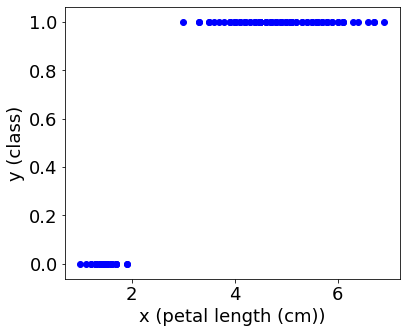

In [21]:
Xdata = np.array( iris_data[:, 2] ) # features is 'petal length (cm)'
y = bin_target # 0 means class 'setosa', 1 means class 'non-setosa' (the other two types)

fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.scatter(Xdata, y, marker='o', color='b')
ax.set_xlabel('x (petal length (cm))'); ax.set_ylabel('y (class)')


Le modèle logistique recherché est de la forme $ \hat{h}(x) = \sigma(w^T x + b)$, òu $\sigma(\cdot)$ est la fonction sigmoïd. 
De manière similaire à l'écriture compacte pour la régression linéaire, on définit le paramètre $\beta$ par $\beta :=(b, w)^{T}\in\mathbb{R}^2$. Par conséquent, on transforme les données $x_i$ par $x_i \leftarrow (1, x_i)$. 

In [118]:
n = Xdata.shape[0]
# ajuster la matrice Xdata 
X = np.column_stack((np.ones(n), Xdata)) 
print('Check out a few lines of the matrix X')
pd.DataFrame(X).head() 

Check out a few lines of the matrix X


,0,1
0,1.0,1.4
1,1.0,1.4
2,1.0,1.3
3,1.0,1.5
4,1.0,1.4


#### Question (i) 

A l'aide de l'Exercice 4.1, on trouve qu'un point $\beta_0 = (-3w_0, w_0)$, pour $w_0=2.5$, est un paramètre assez pertinent pour le modèle de régression logistique sur l'ensemble $\mathcal{D}$.

Justifier pourquoi ce point $\beta_0$ donné est un paramètre pertinent. Pouvez-vous proposer un autre paramètre $\beta$ meilleur que $\beta_0$ (selon le risque empirique définit en cours) ?  

In [45]:
w_trial = 2.5
beta_trial = np.array([-3*w_trial, w_trial])
print(beta_trial.shape) 
print(beta_trial)    

(2,)
[-7.5  2.5]


**Visualiser** le modèle avec $\beta_0$ : 

Text(0, 0.5, 'y')

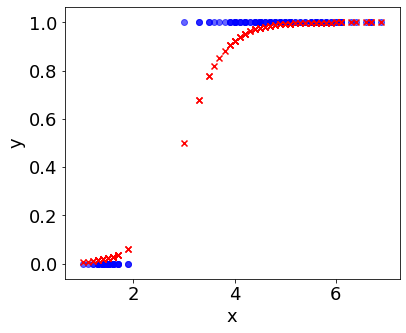

In [46]:
def sigmoid(z): 
    return 1 / (1 + np.exp(-z))

def h_logistic( x, beta ):
    return sigmoid(x.dot(beta))

fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.scatter(X[:,1], y, marker='o', color='b', alpha=0.6)
hvals = [ h_logistic(x, beta_trial) for x in X ]
ax.scatter(X[:,1], hvals, marker='x', color='r')
ax.set_xlabel('x'); ax.set_ylabel('y') 
# fig.savefig('out4_linreg.pdf', format='pdf', bbox_inches = 'tight')


#### Question (ii) 
Compléter la fonction suivante pour le calcul du risique empirique. 


In [ ]:
def compute_empiricalRisk(X, y, beta):
    n = y.shape[0]
    hvals = np.array( [ h_logistic(x, beta) for x in X ] ) 
    J = -np.sum( y*np.log( hvals ) + (1-y) * np.log(1-hvals) )
    return J

Visualiser le risque empirique (voir Eq. (1), Exercices 4) sur le plan 2D avec les lignes de niveau : 

/Users/Shuyu/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log
  after removing the cwd from sys.path.
/Users/Shuyu/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in multiply
  after removing the cwd from sys.path.


Text(0, 0.5, '$\\beta_2$')

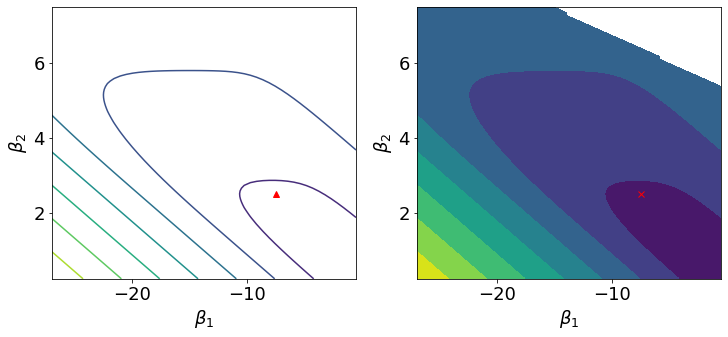

In [120]:
beta1_vals = np.linspace(beta_trial[1]*(0.1), beta_trial[1]*3, 100)
beta0_vals = np.linspace(beta1_vals[0]*(-2.1), beta1_vals[-1]*(-3.6))
J_vals = np.zeros(shape=(len(beta0_vals), len(beta1_vals)))
for i in range(0, len(beta0_vals)):
    for j in range(0, len(beta1_vals)):
        J_vals[i,j] = compute_empiricalRisk(X, y, [[beta0_vals[i]], [beta1_vals[j]]])

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].contour(beta0_vals, beta1_vals, np.transpose(J_vals))
ax[0].plot(beta_trial[0], beta_trial[1], marker='^', color='r');
ax[0].set_xlabel(r'$\beta_1$'); ax[0].set_ylabel(r'$\beta_2$')
# fig.savefig('out4_linregContour.pdf', format='pdf', bbox_inches = 'tight')
ax[1].contourf(beta0_vals, beta1_vals, np.transpose(J_vals))
ax[1].plot(beta_trial[0], beta_trial[1], marker='x', color='r');
ax[1].set_xlabel(r'$\beta_1$'); ax[1].set_ylabel(r'$\beta_2$')

NOTE: On se donne une version alternative pour le calcul du risque empirique, qui est plus stable numériquement autour des points où $P(Y=1|X=x)$ est très proche de $1$ ou de $0$. 

Text(0, 0.5, '$\\beta_2$')

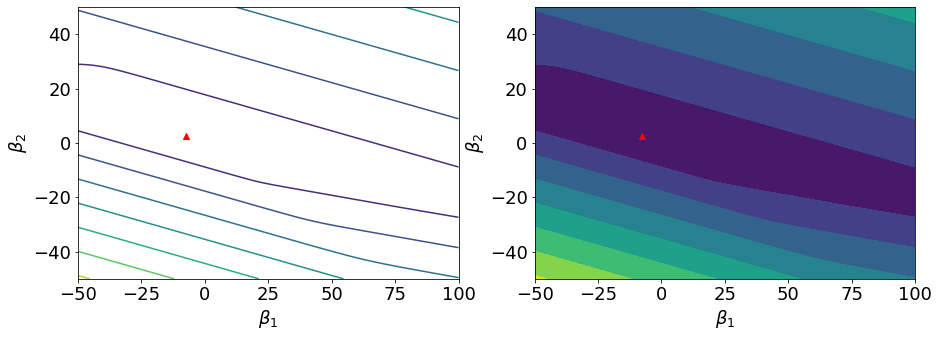

In [115]:
def compute_empiricalRisk_stable(X, y, beta):
    n = y.shape[0]
    # hint: we use 'np.logaddexp(0,z)' to compute log(1+e^z) for more stable behavior when
    z = X @ beta
    J = np.sum( np.logaddexp(0,z) - y * z )
    return J

beta1_vals = np.linspace(beta_trial[1]*(-20), beta_trial[1]*20, 100)
beta0_vals = np.linspace(-50, 100, 100)


J_vals = np.zeros(shape=(len(beta0_vals), len(beta1_vals)))
for i in range(0, len(beta0_vals)):
    for j in range(0, len(beta1_vals)):
        J_vals[i,j] = compute_empiricalRisk_stable(X, y, [[beta0_vals[i]], [beta1_vals[j]]])


fig, ax = plt.subplots(1, 2, figsize=(15,5))
ax[0].contour(beta0_vals, beta1_vals, np.transpose(J_vals))
ax[0].plot(beta_trial[0], beta_trial[1], marker='^', color='r');
ax[0].set_xlabel(r'$\beta_1$'); ax[0].set_ylabel(r'$\beta_2$')
# fig.savefig('out4_linregContour.pdf', format='pdf', bbox_inches = 'tight')
ax[1].contourf(beta0_vals, beta1_vals, np.transpose(J_vals))
ax[1].plot(beta_trial[0], beta_trial[1], marker='^', color='r');
ax[1].set_xlabel(r'$\beta_1$'); ax[1].set_ylabel(r'$\beta_2$')


#### Question (iii) 
Remplir la fonction `compute_gradient(X, y, beta)`. Puis visualiser les gradients sur les quelques points donnés autour de $\beta_0$. 


In [111]:
def compute_gradient(X, y, beta): 
    z = X @ beta 
    return X.T @ (sigmoid(z) - y )

#### Visualisation de gradients $\text{grad}f(\beta)$ sur quelques points 

In [112]:
betas = []

bs = np.linspace(-30, 40, 7)
# beta_ = np.array([-30, -beta_trial[1]*0.8])
# betas.append(beta_)
for b in bs : 
    #betas.append( np.array([b, -beta_trial[1]*0.8]) )
    betas.append( np.array([b, -20]) )

# beta_ = np.array([-beta_trial[0]*2.5, beta_trial[1]*4.8])
# betas.append(beta_)

bs = np.linspace(-25, 50, 7)
for b in bs : 
    betas.append( np.array([b, 40]) )

#ngrads1 =  np.zeros(shape=(len(betas[0]), len(betas[1])))
#ngrads2 =  np.zeros(shape=(len(betas[0]), len(betas[1])))
ngrads = []
for i in range(0, len(betas) ):
        #J_vals[i,j] = compute_cost_one_variable(X, y, [[beta0_vals[i]], [beta1_vals[j]]])
        grad = compute_gradient(X, y, betas[i]  )
        if i == 0:
            n0 = np.linalg.norm(grad)
        ngrad = - 20 * grad / n0
        ngrads.append( ngrad )


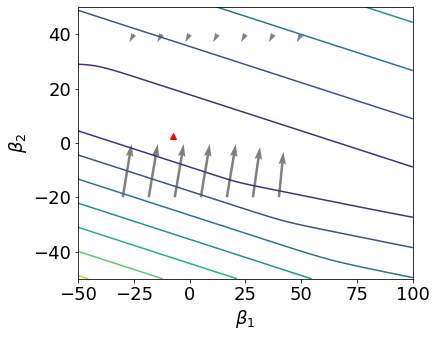

In [114]:
betas = np.array(betas)
ngrads = np.array(ngrads)

# print(J_vals)
fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.contour(beta0_vals, beta1_vals, np.transpose(J_vals))
ax.plot(beta_trial[0], beta_trial[1], marker='^', color='r');
ax.set_xlabel(r'$\beta_1$'); ax.set_ylabel(r'$\beta_2$')

ax.quiver(betas[:,0], betas[:,1], ngrads[:,0], ngrads[:,1],
            angles='xy', scale_units='xy', scale=1, color='gray', alpha=1)

#### Question (iv) 
Donner votre observation des gradients sur les points donnés. En particulier, expliquer la tendance des normes de ces gradients par rapport à leur positions sur le plan.